#Telco customer churn analysis

In [1]:
from google.colab import files
uploaded=files.upload()

Saving archive (5).zip to archive (5).zip


In [5]:
import pandas as pd
import io
import zipfile

# Get the name of the uploaded zip file (assuming only one was uploaded)
zip_file_name = list(uploaded.keys())[0]

# Open the zip file from memory
with zipfile.ZipFile(io.BytesIO(uploaded[zip_file_name]), 'r') as zf:
    # Assuming the CSV file is directly inside the zip archive, get its name
    csv_file_name = [name for name in zf.namelist() if name.endswith('.csv')][0]

    # Read the CSV file into a pandas DataFrame
    with zf.open(csv_file_name) as f:
        df = pd.read_csv(f)

print(df)

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL             No  ...   
1        

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#DATA CLEANING


In [8]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [11]:
# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Convert 'SeniorCitizen' to object/category type for better representation
df['SeniorCitizen'] = df['SeniorCitizen'].astype(object)

print("DataFrame info after type conversions:")
df.info()
print("\nDataFrame head after type conversions:")
display(df.head())

DataFrame info after type conversions:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Pap

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


#Exploratory Data Analysis




### Target Variable Analysis: Churn

Let's analyze the distribution of our target variable `Churn`.

Churn distribution (counts):
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn distribution (percentages):
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


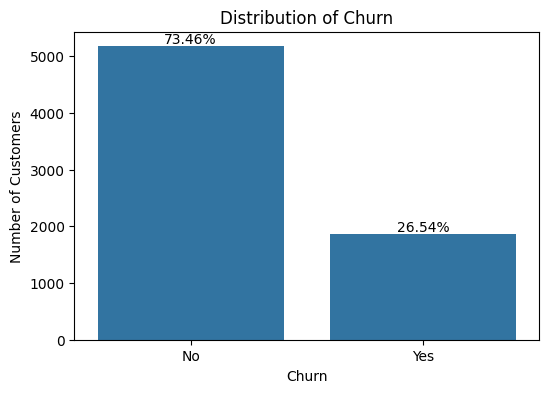

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the value counts of the 'Churn' column
churn_counts = df['Churn'].value_counts()

churn_percentages = df['Churn'].value_counts(normalize=True) * 100

print("Churn distribution (counts):")
print(churn_counts)
print("\nChurn distribution (percentages):")
print(churn_percentages)

# Visualize the Churn distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df)
plt.title('Distribution of Churn')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

# Add percentage labels on top of bars
for index, row in enumerate(churn_counts):
    plt.text(index, row + 50, f'{churn_percentages.iloc[index]:.2f}%', color='black', ha="center")

plt.show()

### Contract Analysis

Let's examine the distribution of contract types and their relationship with churn.

Contract type distribution (counts):
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

Contract type distribution (percentages):
Contract
Month-to-month    55.019168
Two year          24.066449
One year          20.914383
Name: proportion, dtype: float64


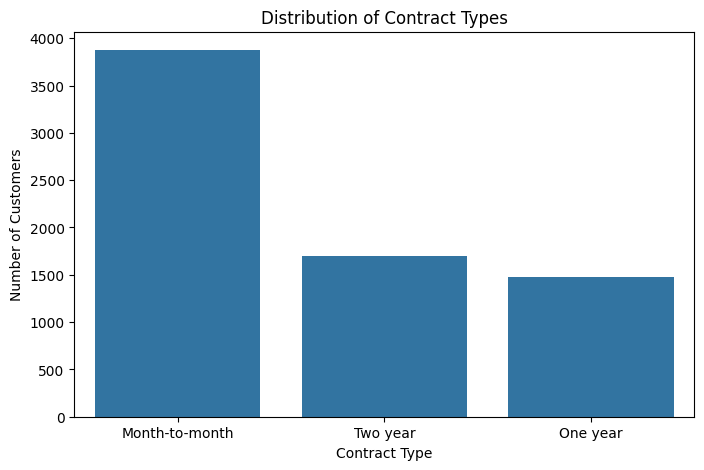

In [23]:
# Get the value counts and percentages of the 'Contract' column
contract_counts = df['Contract'].value_counts()
contract_percentages = df['Contract'].value_counts(normalize=True) * 100

print("Contract type distribution (counts):")
print(contract_counts)
print("\nContract type distribution (percentages):")
print(contract_percentages)

# Visualize the Contract distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=contract_counts.index, y=contract_counts.values)
plt.title('Distribution of Contract Types')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

Customers with month-to-month contracts exhibit significantly higher churn rates compared to customers enrolled in long-term contracts.

#### Churn Rate by Contract Type

Now, let's see how churn varies across different contract types.

Churn rate by Contract type (percentages):
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


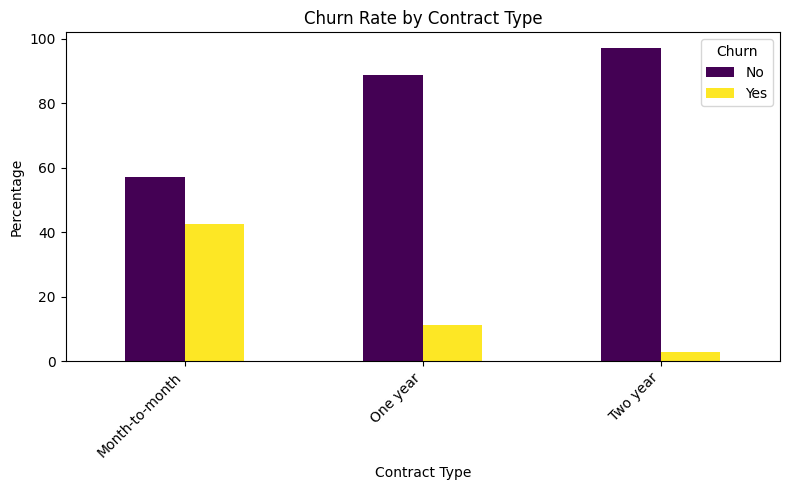

In [24]:
# Calculate churn rate by Contract type
churn_by_contract = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100

print("Churn rate by Contract type (percentages):")
print(churn_by_contract)

# Visualize churn by Contract type
churn_by_contract.plot(kind='bar', figsize=(8, 5), colormap='viridis')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

### Tenure Analysis

Let's analyze the distribution of `tenure` and its impact on churn.

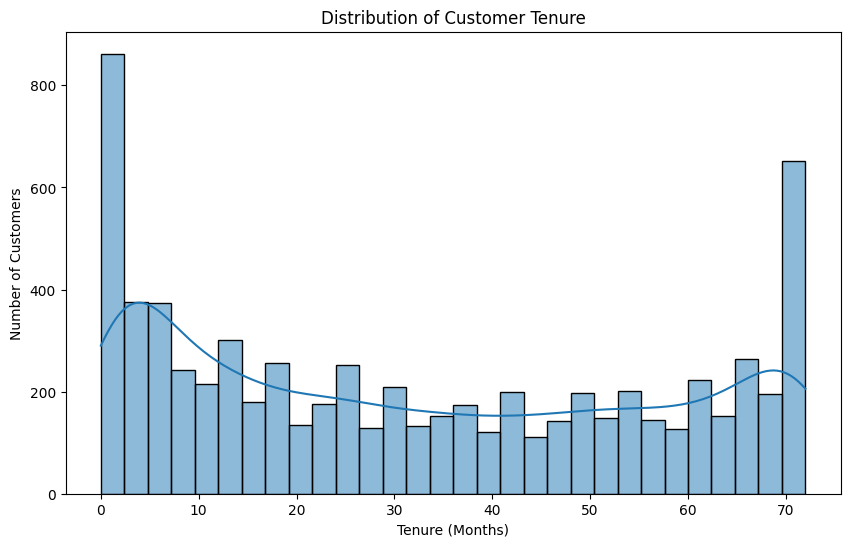

Tenure descriptive statistics:
count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


In [25]:
# Visualize the distribution of tenure
plt.figure(figsize=(10, 6))
sns.histplot(df['tenure'], bins=30, kde=True)
plt.title('Distribution of Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

print("Tenure descriptive statistics:")
print(df['tenure'].describe())

#### Churn Rate by Tenure Group

To better understand the relationship between tenure and churn, let's categorize tenure into groups.

/tmp/ipykernel_3656/2704708902.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_tenure_group = df.groupby('tenure_group')['Churn'].value_counts(normalize=True).unstack() * 100


Churn rate by Tenure Group (percentages):
Churn                No        Yes
tenure_group                      
0-12 M        51.715805  48.284195
13-24 M       70.487106  29.512894
25-48 M       79.125616  20.874384
49-60 M       85.000000  15.000000
61-72 M       91.703836   8.296164


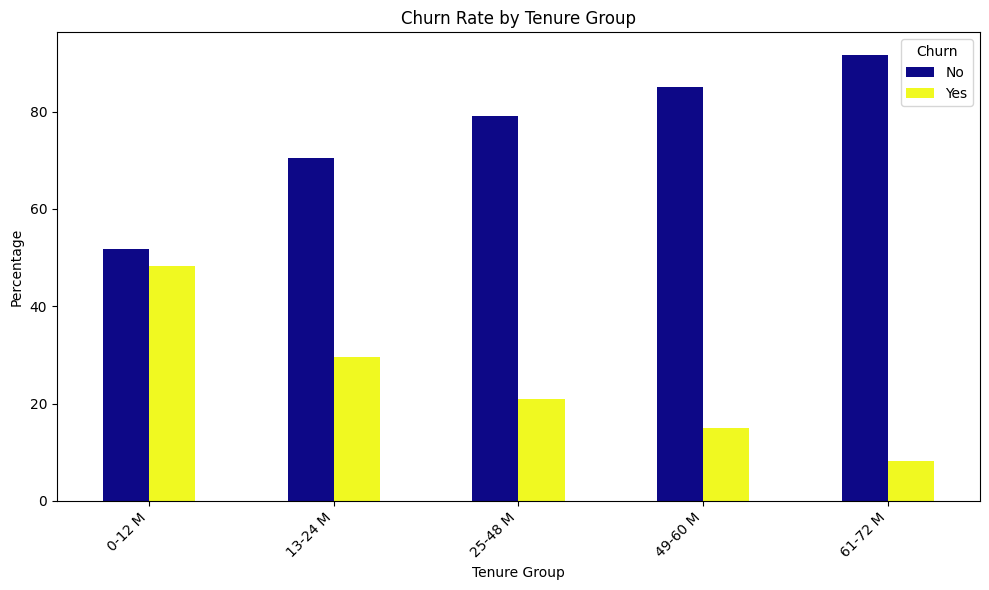

In [26]:
# Create tenure groups
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 60, 72],
                              labels=['0-12 M', '13-24 M', '25-48 M', '49-60 M', '61-72 M'], right=False)

# Calculate churn rate by tenure group
churn_by_tenure_group = df.groupby('tenure_group', observed=False)['Churn'].value_counts(normalize=True).unstack() * 100

print("Churn rate by Tenure Group (percentages):")
print(churn_by_tenure_group)

# Visualize churn by tenure group
churn_by_tenure_group.plot(kind='bar', figsize=(10, 6), colormap='plasma')
plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

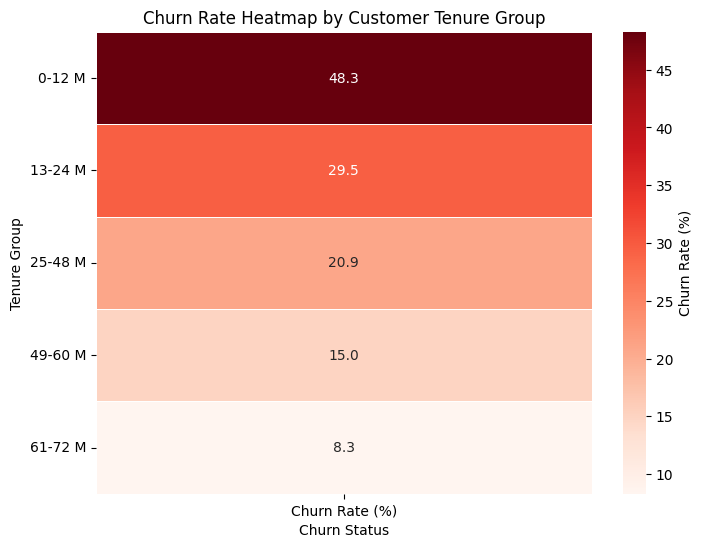

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for heatmap: focus on 'Yes' churn percentage
churn_heatmap_data = churn_by_tenure_group[['Yes']].copy()
churn_heatmap_data.columns = ['Churn Rate (%)']

plt.figure(figsize=(8, 6))
sns.heatmap(churn_heatmap_data, annot=True, fmt=".1f", cmap="Reds", linewidths=.5, cbar_kws={'label': 'Churn Rate (%)'})
plt.title('Churn Rate Heatmap by Customer Tenure Group')
plt.xlabel('Churn Status')
plt.ylabel('Tenure Group')
plt.yticks(rotation=0)
plt.show()

## Retention Analysis: Tech Support

Let's investigate how the presence of 'Tech Support' influences customer churn.

Churn rate by Tech Support (percentages):
Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


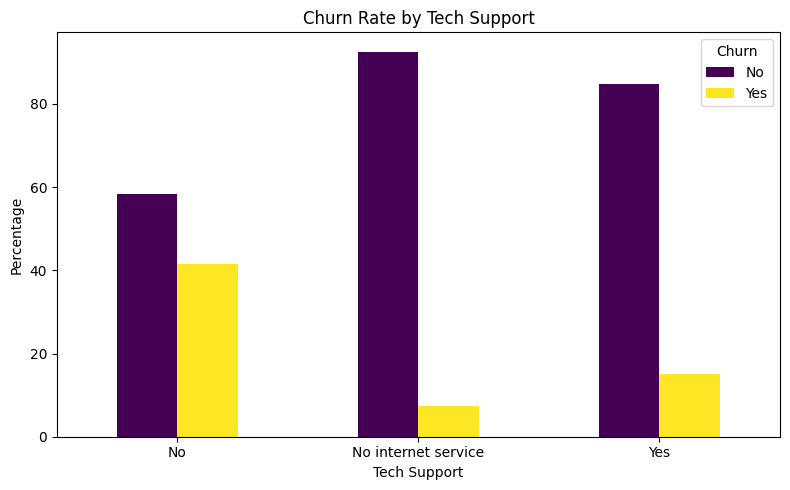

In [34]:
# Calculate churn rate by TechSupport
churn_by_techsupport = df.groupby('TechSupport')['Churn'].value_counts(normalize=True).unstack() * 100

print("Churn rate by Tech Support (percentages):")
print(churn_by_techsupport)

# Visualize churn by TechSupport
fig, ax = plt.subplots(figsize=(8, 5))
churn_by_techsupport.plot(kind='bar', ax=ax, colormap='viridis')
plt.title('Churn Rate by Tech Support')
plt.xlabel('Tech Support')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

## Retention Analysis: Long Contracts

Let's analyze how 'long contracts' (One Year and Two Year) influence customer churn. We have already calculated `churn_by_contract` earlier, so we'll use that to highlight the insights.

Churn rate by Long Contracts (percentages):
Churn            No        Yes
Contract                      
One year  88.730482  11.269518
Two year  97.168142   2.831858


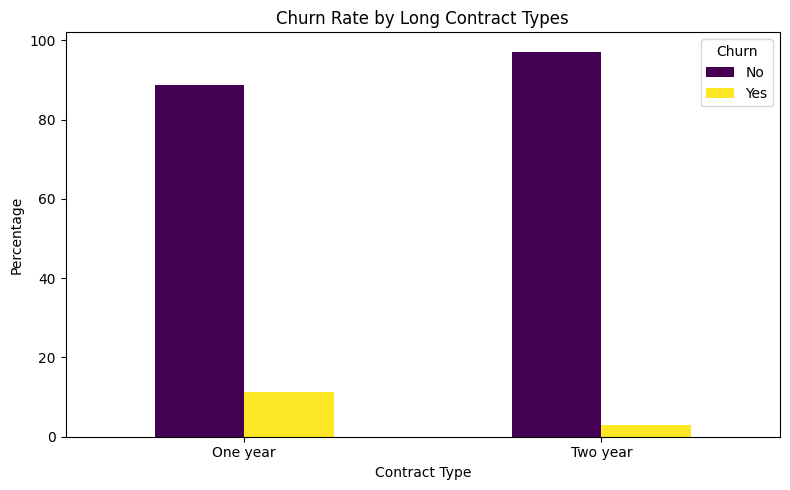

In [35]:
# Display churn rate for long contracts
print("Churn rate by Long Contracts (percentages):")
print(churn_by_contract.loc[['One year', 'Two year']])

# Visualize churn for long contracts
fig, ax = plt.subplots(figsize=(8, 5))
churn_by_contract.loc[['One year', 'Two year']].plot(kind='bar', ax=ax, colormap='viridis')
plt.title('Churn Rate by Long Contract Types')
plt.xlabel('Contract Type')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

## Retention Analysis: Payment Methods

Now, let's investigate the impact of 'Payment Method' on customer churn.

Churn rate by Payment Method (percentages):
Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


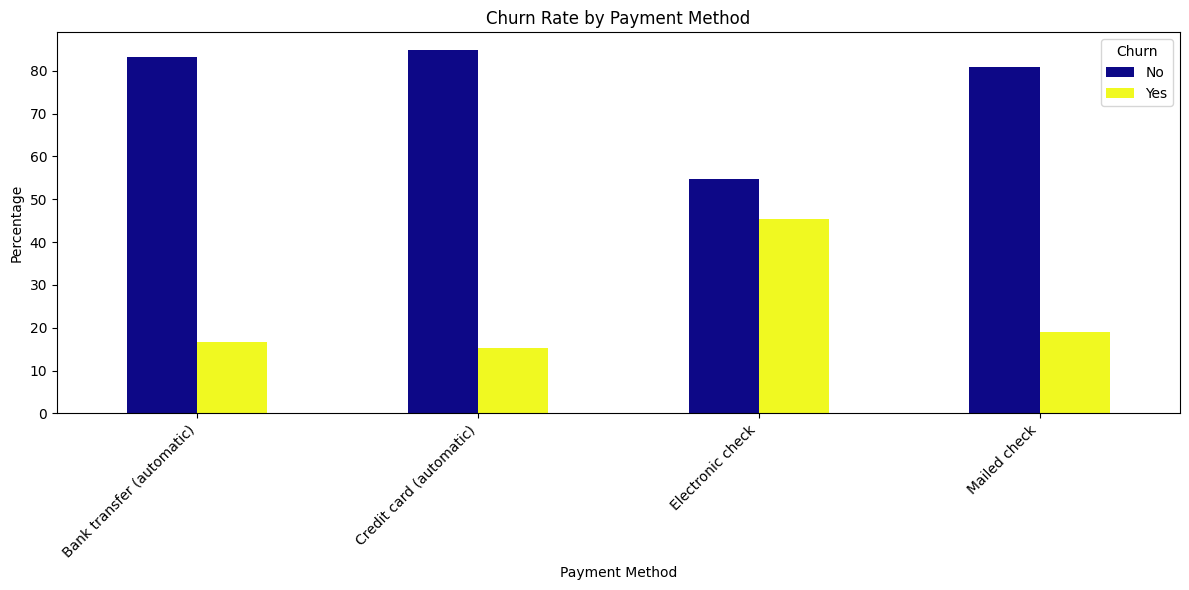

In [36]:
# Calculate churn rate by PaymentMethod
churn_by_paymentmethod = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack() * 100

print("Churn rate by Payment Method (percentages):")
print(churn_by_paymentmethod)

# Visualize churn by PaymentMethod
fig, ax = plt.subplots(figsize=(12, 6))
churn_by_paymentmethod.plot(kind='bar', ax=ax, colormap='plasma')
plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

### Monthly Charges Analysis

Let's analyze the distribution of `MonthlyCharges` and its impact on churn.

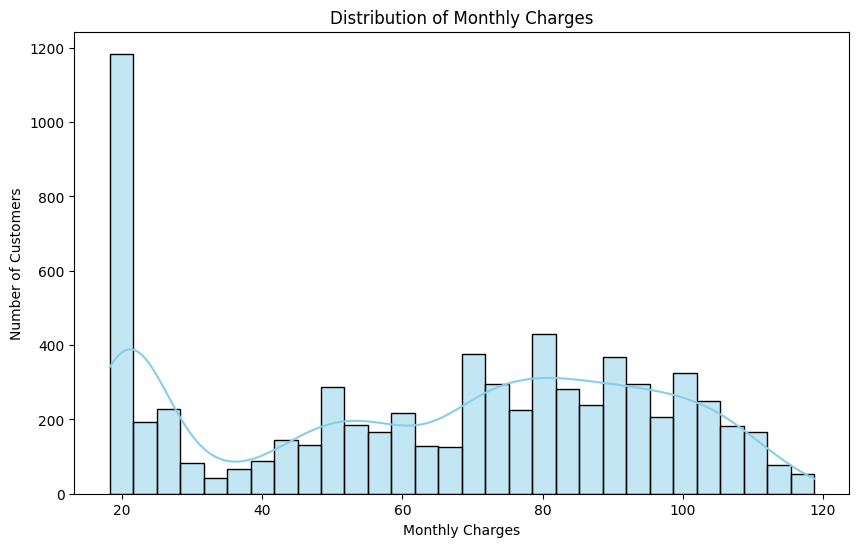

Monthly Charges descriptive statistics:
count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64


In [27]:
# Visualize the distribution of MonthlyCharges
plt.figure(figsize=(10, 6))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.show()

print("Monthly Charges descriptive statistics:")
print(df['MonthlyCharges'].describe())

#### Churn Rate by Monthly Charges Group

To understand the relationship between monthly charges and churn, let's categorize monthly charges into groups.

Churn rate by Monthly Charges Group (percentages):
Churn                        No        Yes
MonthlyCharges_group                      
Low                   88.762770  11.237230
Medium                75.424689  24.575311
High                  62.492886  37.507114
Very High             67.121729  32.878271


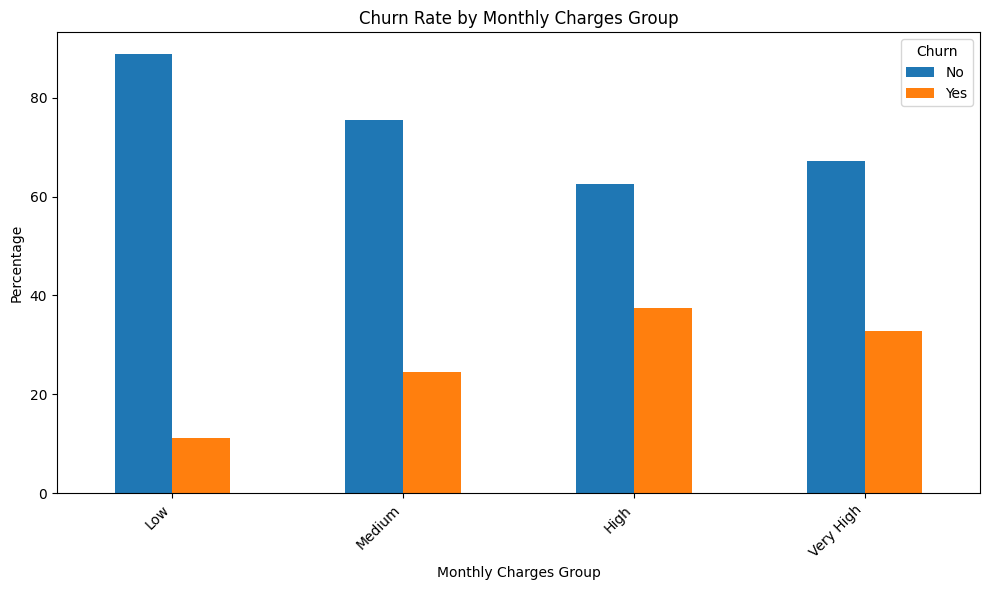

In [31]:
# Create MonthlyCharges groups
# Using qcut for quantiles to ensure a balanced number of customers in each group
df['MonthlyCharges_group'] = pd.qcut(df['MonthlyCharges'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

# Calculate churn rate by MonthlyCharges group
churn_by_monthlycharges_group = df.groupby('MonthlyCharges_group', observed=False)['Churn'].value_counts(normalize=True).unstack() * 100

print("Churn rate by Monthly Charges Group (percentages):")
print(churn_by_monthlycharges_group)

# Visualize churn by MonthlyCharges group
churn_by_monthlycharges_group.plot(kind='bar', figsize=(10, 6))
plt.title('Churn Rate by Monthly Charges Group')
plt.xlabel('Monthly Charges Group')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

## Insights from Monthly Charges Analysis

1. Customers with low monthly charges have the lowest churn rate, while customers with high monthly charges are more likely to leave the service.

2. The ‘Very High’ monthly charges group shows slightly lower churn than the ‘High’ group, possibly because these customers receive better premium services or benefits.

3. Customers in the ‘High’ monthly charges category should be the main focus for retention strategies to reduce customer loss.

## Risk Segmentation

To further understand customer churn, we can segment customers into different risk categories based on factors that strongly influence churn. We'll use 'Contract' type and 'tenure_group' as primary indicators to define these segments.

### Defining Risk Segments

We will define the following risk segments:

*   **Very High Risk:** Customers with 'Month-to-month' contracts and '0-12 M' tenure.
*   **High Risk:** Customers with 'Month-to-month' contracts (but not in the 'Very High Risk' tenure group).
*   **Medium Risk:** Customers with 'One year' contracts.
*   **Low Risk:** Customers with 'Two year' contracts.

In [37]:
import numpy as np

conditions = [
    (df['Contract'] == 'Month-to-month') & (df['tenure_group'] == '0-12 M'),
    (df['Contract'] == 'Month-to-month'),
    (df['Contract'] == 'One year'),
    (df['Contract'] == 'Two year')
]

choices = ['Very High Risk', 'High Risk', 'Medium Risk', 'Low Risk']

df['Risk_Segment'] = np.select(conditions, choices, default='Other')

print("Risk Segment distribution:")
print(df['Risk_Segment'].value_counts())

display(df.head())

Risk Segment distribution:
Risk_Segment
High Risk         1967
Very High Risk    1908
Low Risk          1695
Medium Risk       1473
Name: count, dtype: int64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,MonthlyCharges_group,Risk_Segment
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 M,Low,Very High Risk
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,25-48 M,Medium,Medium Risk
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12 M,Medium,Very High Risk
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48 M,Medium,Medium Risk
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12 M,High,Very High Risk


### Churn Rate by Risk Segment

Now, let's analyze the churn rate across these newly defined risk segments to validate our segmentation strategy.

Churn rate by Risk Segment (percentages):
Churn                  No        Yes
Risk_Segment                        
High Risk       66.243010  33.756990
Low Risk        97.168142   2.831858
Medium Risk     88.730482  11.269518
Very High Risk  48.060797  51.939203


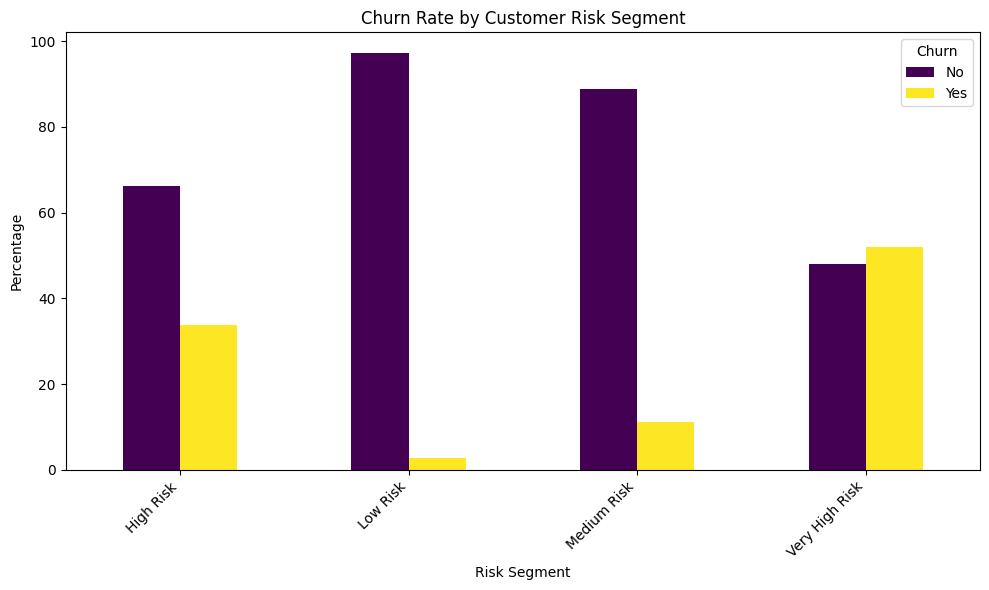

In [38]:
# Calculate churn rate by Risk Segment
churn_by_risk_segment = df.groupby('Risk_Segment', observed=False)['Churn'].value_counts(normalize=True).unstack() * 100

print("Churn rate by Risk Segment (percentages):")
print(churn_by_risk_segment)

# Visualize churn by Risk Segment
fig, ax = plt.subplots(figsize=(10, 6))
churn_by_risk_segment.plot(kind='bar', ax=ax, colormap='viridis')
plt.title('Churn Rate by Customer Risk Segment')
plt.xlabel('Risk Segment')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

## Export Cleaned Data

Now, let's export the cleaned DataFrame to a CSV file. This file will include all the new features and risk segments we've created.

In [39]:
# Save the cleaned DataFrame to a CSV file
df.to_csv('cleaned_customer_churn.csv', index=False)

print("Cleaned data exported to 'cleaned_customer_churn.csv'")

Cleaned data exported to 'cleaned_customer_churn.csv'
